<a href="https://colab.research.google.com/github/luan3642/Machine_learning_classificacao_sklearn-ALURA/blob/main/aula01_alura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# features [1 sim, 0 nao]
# pelo longo?
# perna curta?
# faz auau?


porco1 = [0,1,0]
porco2 = [0,1,1]
porco3 = [1,1,0]

In [2]:
cachorro1 = [0,1,1]
cachorro2 = [1,0,1]
cachorro3 = [1,1,1]

1 -> porco 0 -> cachorro

In [3]:
treino_x = [porco1, porco2, porco3, cachorro1, cachorro2, cachorro3]

In [4]:
treino_y = [1,1,1, 0,0,0]

In [5]:
treino_x

[[0, 1, 0], [0, 1, 1], [1, 1, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]]

In [6]:
from sklearn.svm import LinearSVC

modelo = LinearSVC()
modelo.fit(treino_x, treino_y)

LinearSVC()

In [7]:
animal_misterioso = [0,0,0]
modelo.predict([animal_misterioso])

array([1])

In [8]:
misterio1 = [1,1,1]
misterio2 = [1,1, 0]
misterio3 = [0,1,1]

In [9]:
teste_x = [misterio1, misterio2, misterio3]
previsoes = modelo.predict(teste_x)

In [10]:
previsoes

array([0, 1, 0])

In [11]:
testes_y = [0,1,1]

In [12]:
corretos = (previsoes == testes_y).sum()

In [13]:
corretos

np.int64(2)

In [14]:
total = len(teste_x)

In [15]:
taxa_acerto = corretos / total * 100

In [16]:
taxa_acerto

np.float64(66.66666666666666)

In [17]:
print(f"acucurácia: {taxa_acerto:.2f}%" )

acucurácia: 66.67%


In [18]:
from sklearn.metrics import accuracy_score

taxa_acerto = accuracy_score(testes_y, previsoes) * 100
print(f"taxa de acerto: {taxa_acerto:.2f}%")

taxa de acerto: 66.67%


#AULA 02

In [19]:
import pandas as pd

uri = "https://gist.githubusercontent.com/guilhermesilveira/b9dd8e4b62b9e22ebcb9c8e89c271de4/raw/c69ec4b708fba03c445397b6a361db4345c83d7a/tracking.csv"
dados = pd.read_csv(uri)
dados.head()

,inicial,palestras,contato,comprou,patrocinio
0,1,1,0,0,0
1,1,1,0,0,0
2,1,1,0,0,0
3,1,1,0,0,0
4,1,1,0,0,0


In [20]:
y = dados['comprou']
y.head()

,comprou
0,0
1,0
2,0
3,0
4,0


In [21]:
x = dados[['inicial','palestras',	'contato'	,	'patrocinio']]
x.head()

,inicial,palestras,contato,patrocinio
0,1,1,0,0
1,1,1,0,0
2,1,1,0,0
3,1,1,0,0
4,1,1,0,0


In [22]:
dados.shape

(99, 5)

In [23]:
treinoX = x[:75]
treinoY = y[:75]

testeX = x[75:]
testeY = y[75:]

print(f'treinaremos com este numero de  {len(treinoX)} elementos')
print(f'testando com este numero de  {len(testeX)} elementos')

treinaremos com este numero de  75 elementos
testando com este numero de  24 elementos


In [24]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

modelo = LinearSVC()
modelo.fit(treinoX,treinoY)

previsoes = modelo.predict(testeX)

acuracia = accuracy_score(testeY, previsoes) * 100
print(f'acuracia: {acuracia:.2f}%')

acuracia: 95.83%


# usando biblioteca para separar em treino e teste

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

SEED = 290

treino_x, teste_x, treino_y, teste_y = train_test_split(x,y, random_state = SEED, stratify = y)
print(f'treinaremos com este numero de  {len(treino_x)} elementos')
print(f'testando com este numero de  {len(teste_x)} elementos')




modelo = LinearSVC()
modelo.fit(treino_x,treino_y)

previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f'acuracia: {acuracia:.2f}%')

treinaremos com este numero de  74 elementos
testando com este numero de  25 elementos
acuracia: 96.00%


In [26]:
treino_y.value_counts()

,count
comprou,
0,49
1,25


In [27]:
teste_y.value_counts()

,count
comprou,
0,17
1,8


##Aula03

In [28]:
import pandas as pd

uri = "https://gist.githubusercontent.com/guilhermesilveira/12291c548acaf544596795709020e3db/raw/325bdef098bd9cbc2189215b7e32e22f437f29f3/projetos.csv"

In [51]:
dados = pd.read_csv(uri)
dados['finalizados'] = dados['nao_finalizado'].map({1: 0, 0: 1})
dados = dados.query('horas_esperadas > 0')
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizados
0,0,75.0,6985.0,1
2,0,87.0,14205.0,1
3,1,13.0,100.0,0
4,0,2.0,202.0,1
5,0,49.0,1096.0,1


In [30]:
dados["finalizados"] = dados["nao_finalizado"].map({1: 0, 0:1})
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizados
0,0,75.0,6985.000000,1
1,1,0.0,4325.293458,0
2,0,87.0,14205.000000,1
3,1,13.0,100.000000,0
4,0,2.0,202.000000,1


In [31]:
import seaborn as sns

<Axes: xlabel='horas_esperadas', ylabel='preco'>

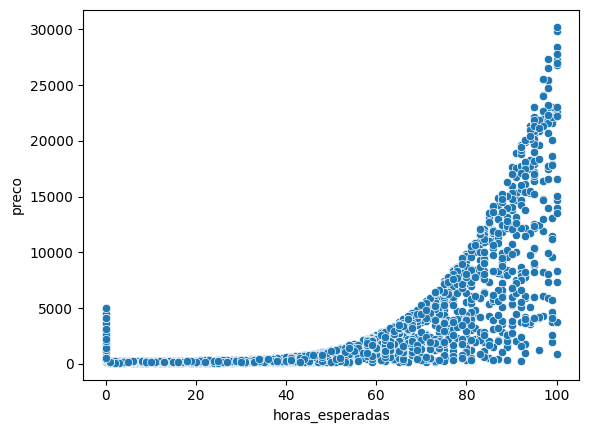

In [32]:
sns.scatterplot(x="horas_esperadas", y = "preco", data = dados)

<Axes: xlabel='horas_esperadas', ylabel='preco'>

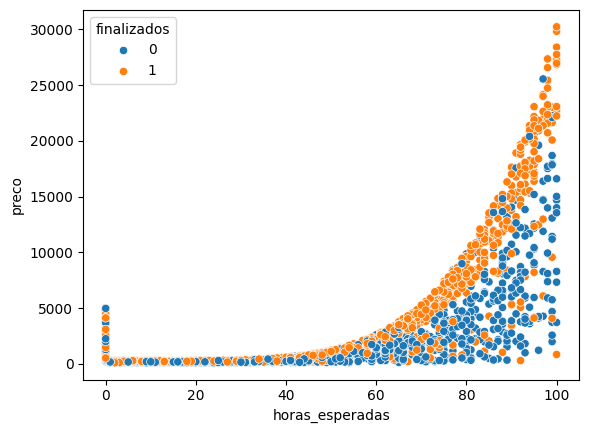

In [33]:
sns.scatterplot(x="horas_esperadas", y = "preco", data = dados, hue = "finalizados")

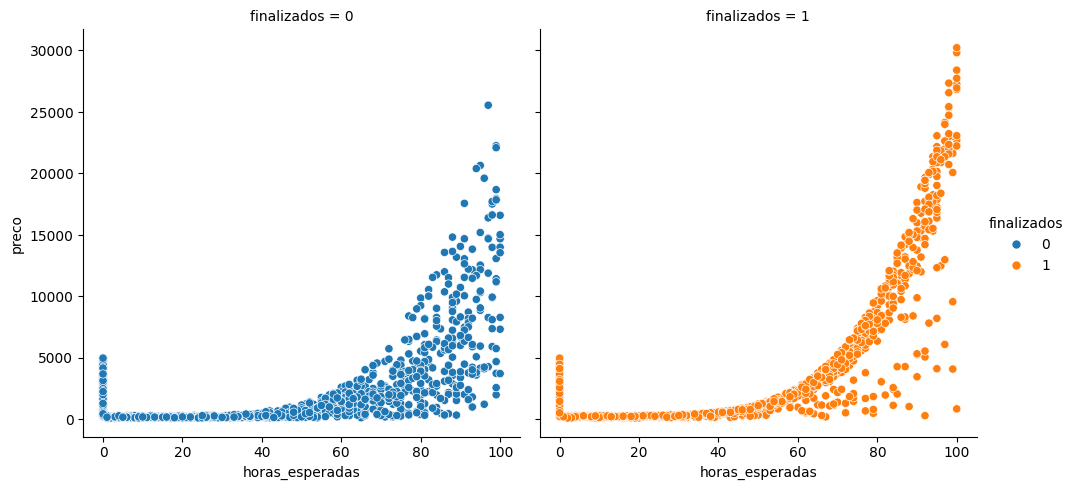

In [34]:
sns.relplot(x="horas_esperadas", y = "preco", data = dados, hue = "finalizados", col = "finalizados")

In [48]:
# jogar fora as linhas com horas esperadas igual a 0
dados = dados.query("horas_esperadas > 0")
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizados
0,0,75.0,6985.0,1
2,0,87.0,14205.0,1
3,1,13.0,100.0,0
4,0,2.0,202.0,1
5,0,49.0,1096.0,1


In [35]:
import matplotlib.pyplot as plt
import numpy as np

x_min = teste_x.horas_esperadas.min()
x_max = teste_x.horas_esperadas.max()
y_min = teste_x.preco.min()
y_max = teste_x.preco.max()

pixels = 100
eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(teste_x.horas_esperadas, teste_x.preco, c=teste_y, s=1)

# DECISION BOUNDARY

In [52]:
x = dados[['horas_esperadas', 'preco']]
y = dados['finalizados']

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

SEED = 20
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, random_state = SEED, test_size = 0.25, stratify = y)

x_min = teste_x['horas_esperadas'].min()
x_max = teste_x['horas_esperadas'].max()
y_min = teste_x['preco'].min()
y_max = teste_x['preco'].max()

print(f'x_min: {x_min}, x_max: {x_max}, y_min: {y_min}, y_max: {y_max}')

x_min: 1.0, x_max: 100.0, y_min: 102.0, y_max: 30223.0


In [54]:
previsoes_de_base = (teste_y.sum() / len(teste_y)) * 100
print(f"Acurácia do algoritmo de baseline: {previsoes_de_base:.2f}%")

Acurácia do algoritmo de baseline: 52.59%


In [55]:
from sklearn.svm import LinearSVC

modelo = LinearSVC(random_state=SEED)
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"Acurácia do LinearSVC: {acuracia:.2f}%")

Acurácia do LinearSVC: 60.56%


In [61]:
import numpy as np

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min) /pixels)

eixo_x

eixo_y = np.arange(y_min, y_max, (y_max - y_min) /pixels)

eixo_y

array([  102.  ,   403.21,   704.42,  1005.63,  1306.84,  1608.05,
        1909.26,  2210.47,  2511.68,  2812.89,  3114.1 ,  3415.31,
        3716.52,  4017.73,  4318.94,  4620.15,  4921.36,  5222.57,
        5523.78,  5824.99,  6126.2 ,  6427.41,  6728.62,  7029.83,
        7331.04,  7632.25,  7933.46,  8234.67,  8535.88,  8837.09,
        9138.3 ,  9439.51,  9740.72, 10041.93, 10343.14, 10644.35,
       10945.56, 11246.77, 11547.98, 11849.19, 12150.4 , 12451.61,
       12752.82, 13054.03, 13355.24, 13656.45, 13957.66, 14258.87,
       14560.08, 14861.29, 15162.5 , 15463.71, 15764.92, 16066.13,
       16367.34, 16668.55, 16969.76, 17270.97, 17572.18, 17873.39,
       18174.6 , 18475.81, 18777.02, 19078.23, 19379.44, 19680.65,
       19981.86, 20283.07, 20584.28, 20885.49, 21186.7 , 21487.91,
       21789.12, 22090.33, 22391.54, 22692.75, 22993.96, 23295.17,
       23596.38, 23897.59, 24198.8 , 24500.01, 24801.22, 25102.43,
       25403.64, 25704.85, 26006.06, 26307.27, 26608.48, 26909

In [62]:
  xx, yy = np.meshgrid(eixo_x, eixo_y)
  xx

array([[ 1.  ,  1.99,  2.98, ..., 97.03, 98.02, 99.01],
       [ 1.  ,  1.99,  2.98, ..., 97.03, 98.02, 99.01],
       [ 1.  ,  1.99,  2.98, ..., 97.03, 98.02, 99.01],
       ...,
       [ 1.  ,  1.99,  2.98, ..., 97.03, 98.02, 99.01],
       [ 1.  ,  1.99,  2.98, ..., 97.03, 98.02, 99.01],
       [ 1.  ,  1.99,  2.98, ..., 97.03, 98.02, 99.01]])